# Outliers in Tara

In [1]:
# imports

from importlib import reload

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from ocpy.tara import io as tara_io
from ocpy.ph import pigments
from ocpy.hydrolight import loisel23

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io

In [2]:
%matplotlib ipympl

# Load

## NMF

In [3]:
nmf_fit = 'Tara'
N_NMF, iop = 4, 'a'
d_L23 = cnmf_io.load_nmf(nmf_fit, N_NMF, iop)
L23_M = d_L23['M']
L23_coeff = d_L23['coeff']
L23_NMF_wave = d_L23['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/Tara/Tara_NMF_04_a.npz


# Reconstruct em

In [4]:
recon = np.dot(d_L23['coeff'], d_L23['M'])

# RMSE

In [5]:
diff = recon - d_L23['spec']

In [6]:
RMSE = np.sqrt(np.mean(diff**2, axis=1))

## Plot

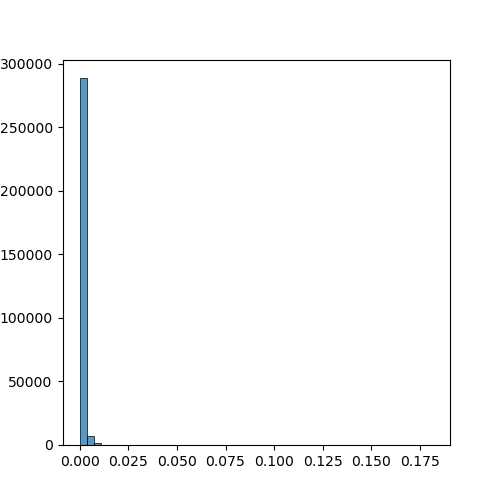

In [7]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()
_ = sns.histplot(RMSE, bins=50)
#
plt.show()

## Extrema

In [8]:
srt_RMSE = np.argsort(RMSE)
high_RMSE = srt_RMSE[-10:]

## Plot a few

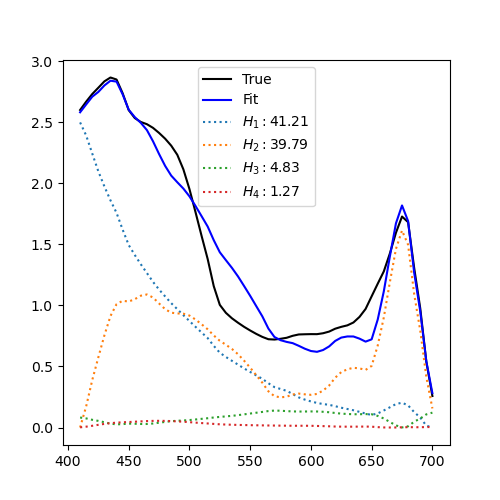

RMSE = 0.18155963344267076, idx=118300, UID=1635946320000000000


In [11]:
idx = high_RMSE[-1]
d = d_L23

fig = plt.figure(figsize=(5,5))
ax = plt.gca()

ax.plot(d['wave'], d['spec'][idx], 'k-', label='True')
ax.plot(d['wave'], recon[idx], 'b-', label='Fit')

# Break it down
for ss in range(d['M'].shape[0]):
    ax.plot(d['wave'], d['M'][ss]*d['coeff'][idx][ss], 
            label=r'$H_'+f'{ss+1}: {d["coeff"][idx][ss]:0.2f}'+'$', ls=':')

ax.legend()
plt.show()
print(f'RMSE = {RMSE[idx]}, idx={idx}, UID={d['UID'][idx]}')

# Relative RMSE

In [12]:
save = [105191, # Pure H1 [shows why the bump was needed]
        161079, # Bad data at 700nm
        105224, # Another with pure H1
        237130, # Strong one with pure H1
        120863, # RMSE; quite distinct, very strong
       ]

In [13]:
anly = d_L23['spec'] > 0.005
rRMSE = np.sqrt(np.mean((diff/recon)**2, axis=1))

In [16]:
srt_rRMSE = np.argsort(rRMSE)
high_rRMSE = srt_rRMSE[-30:]

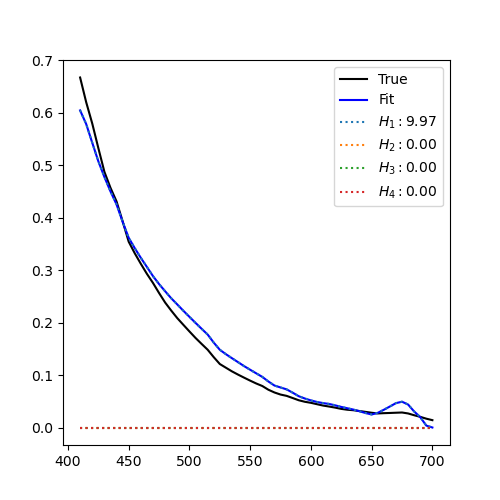

rRMSE = 9.104028681445488e+22, idx=54015, UID=1615303800000000000


In [17]:
idx = high_rRMSE[-11]
#idx = 237130
d = d_L23

fig = plt.figure(figsize=(5,5))
ax = plt.gca()

ax.plot(d['wave'], d['spec'][idx], 'k-', label='True')
ax.plot(d['wave'], recon[idx], 'b-', label='Fit')

# Break it down
for ss in range(d['M'].shape[0]):
    ax.plot(d['wave'], d['M'][ss]*d['coeff'][idx][ss], 
            label=r'$H_'+f'{ss+1}: {d["coeff"][idx][ss]:0.2f}'+'$', ls=':')

ax.legend()
plt.show()
print(f'rRMSE = {rRMSE[idx]}, idx={idx}, UID={d['UID'][idx]}')

In [18]:
np.median(rRMSE)

np.float64(0.05347961960589827)

## Find the strongest in the top 50

In [19]:
i440 = np.argmin(np.abs(d['wave']-440.))
maxI = -1
high_a = 0.
for idx in srt_rRMSE[-50:]:
    if recon[idx,i440] > high_a:
        high_a = recon[idx,i440] 
        maxI = idx
print(maxI)

267304


----

In [30]:
ds = loisel23.load_ds(4,0)

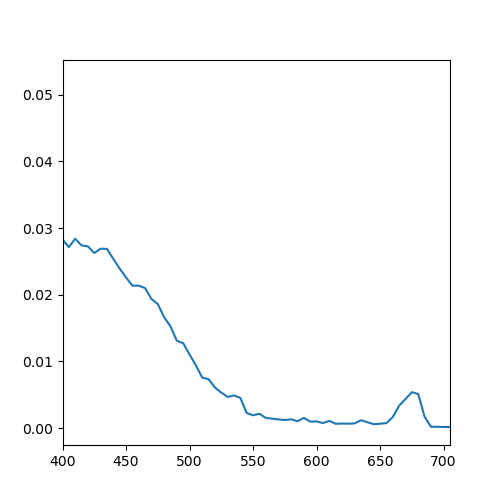

In [33]:
fig = plt.figure(figsize=(5,5))
ax = plt.gca()

ax.plot(ds.Lambda, ds.anw.data[idx])

ax.set_xlim(400., 705)

plt.show()